In [57]:
!pip install seaborn

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

In [59]:
df = pd.read_csv('CT_PET1_AfterComet.csv')
print(f"Dataset successfully loaded. Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")

Dataset successfully loaded. Shape: 734 rows, 294 columns.



In [60]:
# !pip install pyComBat
# from pycombat import pycombat

In [61]:
clean_feature_names = [f.replace('[', '_').replace(']', '_').replace('<', '_').replace('>', '_').replace('-', '_').replace(':', '_')
                     for f in df.columns]
df.columns = clean_feature_names

print("Feature names sanitized! (Forbidden characters [ ] < : removed)")

Feature names sanitized! (Forbidden characters [ ] < : removed)


In [62]:
print("--- Dataset Info ---")
print(df.info())
print("\n--- First 3 Rows ---")
print(df.head(3))

metadata_cols = ['INFO_PatientName', 'INFO_NameOfRoi', 'Batch', 'label']
feature_cols = [col for col in df.columns if col not in metadata_cols]

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Columns: 294 entries, INFO_PatientName to PET1_GLSZM_ZoneSizeEntropy(IBSI_GU8N)
dtypes: float64(290), int64(2), object(2)
memory usage: 1.6+ MB
None

--- First 3 Rows ---
  INFO_PatientName INFO_NameOfRoi  label  Batch  \
0              CT1       Seg1_#11      0      1   
1              CT1       Seg1_#10      0      1   
2              CT1       Seg1_#33      1      1   

   CT_MORPHOLOGICAL_Volume(IBSI_RNU0)_cm3_  \
0                              -130.879031   
1                               -44.598042   
2                                14.415017   

   CT_MORPHOLOGICAL_ApproximateVolume(IBSI_YEKZ)_cm3_  \
0                                        -130.850454    
1                                         -44.531759    
2                                          14.463025    

   CT_MORPHOLOGICAL_voxelsCounting(IBSI_No)_#vx_  \
0                                 -130850.452882   
1            

In [63]:
print("\n--- Patient and Batch Unique Counts ---")
print(f"Unique Patients: {df['INFO_PatientName'].nunique()}")
print(f"Unique Regions of Interest (ROIs): {df['INFO_NameOfRoi'].nunique()}")
print(f"Unique Batches: {df['Batch'].nunique()}")

# repeated patients
patient_counts = df['INFO_PatientName'].value_counts()
print(f"Max samples for a single patient: {patient_counts.max()}")
print(f"Min samples for a single patient: {patient_counts.min()}")


--- Patient and Batch Unique Counts ---
Unique Patients: 24
Unique Regions of Interest (ROIs): 734
Unique Batches: 2
Max samples for a single patient: 108
Min samples for a single patient: 10


In [64]:
print("\n--- Summary Statistics for Key Morphological Features ---")
print(df[feature_cols[:5]].describe().T)


--- Summary Statistics for Key Morphological Features ---
                                                    count           mean  \
CT_MORPHOLOGICAL_Volume(IBSI_RNU0)_cm3_             734.0     211.550192   
CT_MORPHOLOGICAL_ApproximateVolume(IBSI_YEKZ)_cm3_  734.0     211.662614   
CT_MORPHOLOGICAL_voxelsCounting(IBSI_No)_#vx_       734.0  211662.613547   
CT_MORPHOLOGICAL_SurfaceArea(IBSI_C0JK)_cm2_        734.0     267.130794   
CT_MORPHOLOGICAL_SurfaceToVolumeRatio(IBSI_2PR5...  734.0       3.783901   

                                                              std  \
CT_MORPHOLOGICAL_Volume(IBSI_RNU0)_cm3_                452.616487   
CT_MORPHOLOGICAL_ApproximateVolume(IBSI_YEKZ)_cm3_     452.712597   
CT_MORPHOLOGICAL_voxelsCounting(IBSI_No)_#vx_       452712.595091   
CT_MORPHOLOGICAL_SurfaceArea(IBSI_C0JK)_cm2_           477.117222   
CT_MORPHOLOGICAL_SurfaceToVolumeRatio(IBSI_2PR5...       2.179618   

                                                              min  \


In [65]:
print("\n--- Missing and Infinite Values Check ---")
null_counts = df[feature_cols].isnull().sum()
inf_counts = df[feature_cols].apply(lambda x: np.isinf(x).sum())

missing_summary = pd.DataFrame({'Missing (NaN)': null_counts, 'Infinite (Inf)': inf_counts})
problematic_cols = missing_summary[(missing_summary['Missing (NaN)'] > 0) | (missing_summary['Infinite (Inf)'] > 0)]

if not problematic_cols.empty:
    print("Features containing NaN or Inf values:")
    print(problematic_cols)
else:
    print("Clean! No missing (NaN) or infinite (Inf) values found in the feature columns.")


--- Missing and Infinite Values Check ---
Clean! No missing (NaN) or infinite (Inf) values found in the feature columns.


/var/folders/rf/x4s3m6qd51gcvc25nv1bpdl40000gn/T/ipykernel_7839/2497580508.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="label", palette="Set2")


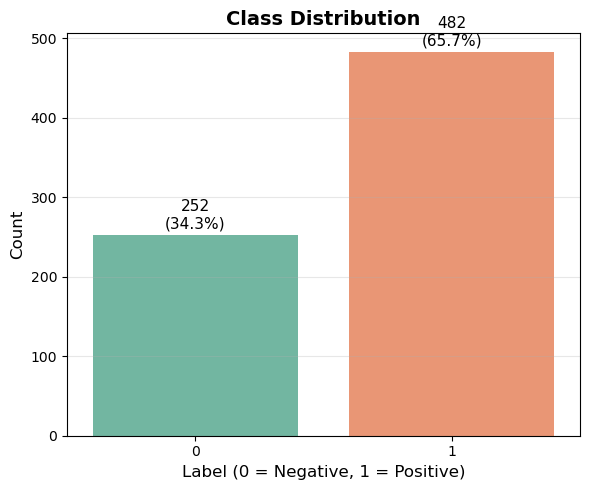

In [67]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x="label", palette="Set2")
plt.title("Class Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Negative, 1 = Positive)", fontsize=12)
plt.ylabel("Count", fontsize=12)

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(f'{count}\n({percentage})', 
                (p.get_x() + p.get_width()/2., p.get_height() + 5),
                ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

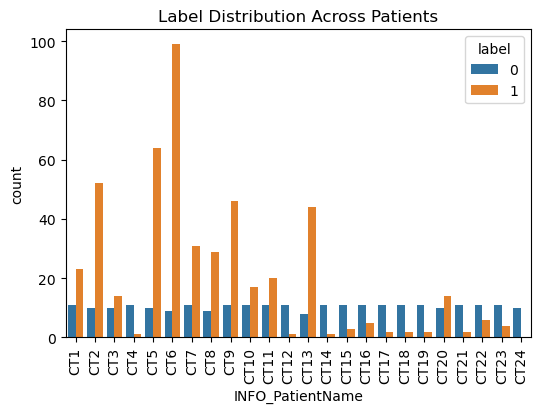

In [ ]:
# plt.figure(figsize=(6,4))
# sns.countplot(data=df, x="INFO_PatientName", hue="label")
# plt.xticks(rotation=90)
# plt.title("Label Distribution Across Patients")
# plt.show()

<Figure size 1000x600 with 0 Axes>

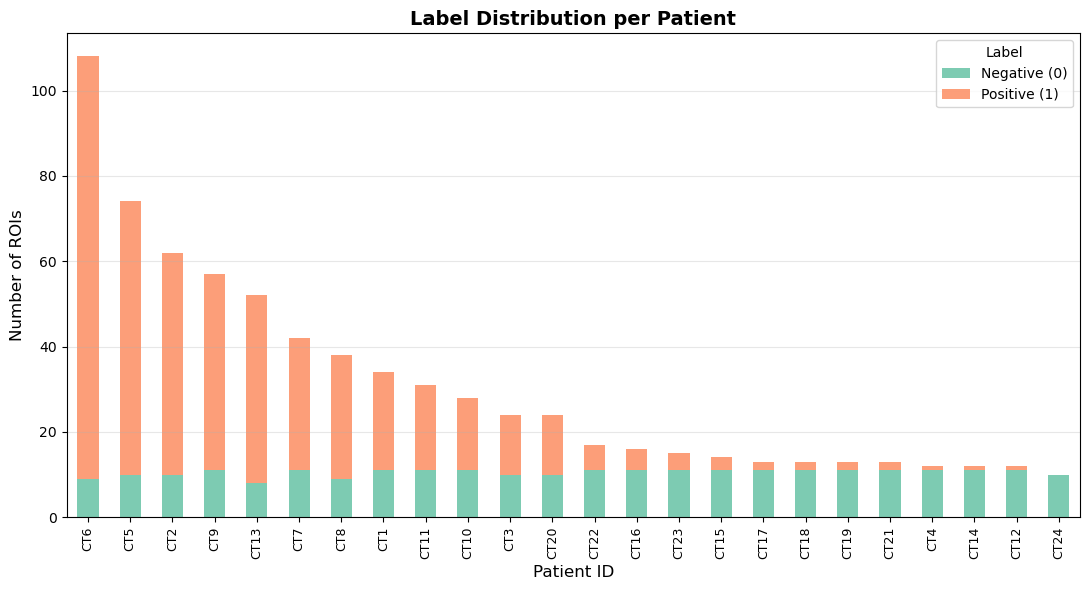

In [70]:
plt.figure(figsize=(10,6))
patient_label = df.groupby('INFO_PatientName')['label'].value_counts().unstack(fill_value=0)
patient_label['Total'] = patient_label.sum(axis=1)
patient_label = patient_label.sort_values('Total', ascending=False)

patient_label[[0,1]].plot(kind='bar', stacked=True, figsize=(11,6), 
                             color=['#66c2a5', '#fc8d62'], alpha=0.85)

plt.title("Label Distribution per Patient", fontsize=14, fontweight='bold')
plt.xlabel("Patient ID", fontsize=12)
plt.ylabel("Number of ROIs", fontsize=12)
plt.legend(title="Label", labels=["Negative (0)", "Positive (1)"])
plt.xticks(rotation=90, fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

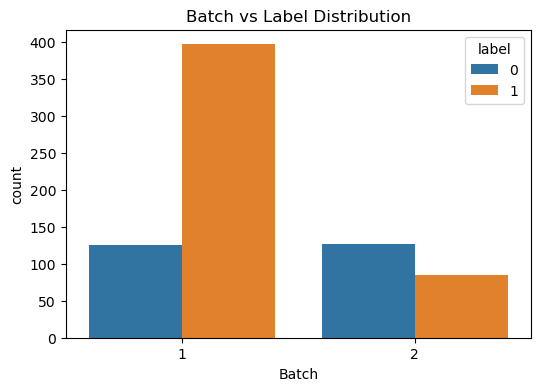

In [71]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Batch", hue="label")
plt.title("Batch vs Label Distribution")
plt.show()

In [72]:
metadata_cols = ['INFO_PatientName', 'INFO_NameOfRoi', 'Batch', 'label']
feature_cols = [col for col in df.columns if col not in metadata_cols]

y = df["label"].values
groups = df["INFO_PatientName"].values


X = df.drop(columns=["label", "INFO_PatientName"])

X = X.drop(columns=["Batch", "INFO_NameOfRoi"], errors="ignore")

X = X.select_dtypes(include=[np.number])

X = X.replace([np.inf, -np.inf], np.nan)


In [73]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

class CorrelationFilter(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):

        X_df = pd.DataFrame(X)

        corr = X_df.corr().abs()

        upper = corr.where(
            np.triu(np.ones(corr.shape), k=1).astype(bool)
        )

        self.keep_columns_ = [
            col for col in upper.columns
            if not any(upper[col] > self.threshold)
        ]

        return self

    def transform(self, X):

        X_df = pd.DataFrame(X)

        return X_df.iloc[:, self.keep_columns_]

In [74]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

feature_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=300, random_state=42),
    max_features=10
)

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def build_pipeline(model):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("corr_filter", CorrelationFilter(threshold=0.95)),
        ("feature_select", feature_selector),
        ("classifier", model)
    ])

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier


models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "LinearSVM": SVC(kernel="linear", probability=True),
    "RBF_SVM": SVC(kernel="rbf", probability=True),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
    "NaiveBayes": GaussianNB()
}

param_grids = {
    "LogReg": {
        "classifier__C": [0.01, 0.1, 1, 10]
    },

    "LinearSVM": {
        "classifier__C": [0.01, 0.1, 1, 10]
    },

    "RBF_SVM": {
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": ["scale", 0.01, 0.1]
    },

    "RandomForest": {
        "classifier__n_estimators": [100, 300],
        "classifier__max_depth": [3, 5, None]
    },

    "XGBoost": {
        "classifier__max_depth": [2, 3, 4],
        "classifier__learning_rate": [0.01, 0.1]
    },

    "NaiveBayes": {}
}

In [81]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

n_outer = 5
n_repeats = 10
random_state = 42

results = []
roc_data = {}

outer_cv_base = GroupKFold(n_splits=n_outer)

for model_name, model in models.items():
    print(f"\nRunning Repeated Nested CV for: {model_name}")
    
    outer_scores = []
    fpr_list = []
    tpr_list = []
    
    for repeat in range(n_repeats):
        np.random.seed(random_state + repeat)
        
        for train_idx, test_idx in outer_cv_base.split(X, y, groups):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            groups_train = groups[train_idx]

            pipeline = build_pipeline(model)

            inner_cv = GroupKFold(n_splits=3)
            
            search = GridSearchCV(
                pipeline,
                param_grids[model_name],
                cv=inner_cv,
                scoring="roc_auc",
                n_jobs=1
            )

            search.fit(X_train, y_train, groups=groups_train)
            best_model = search.best_estimator_

            if hasattr(best_model, "predict_proba"):
                y_prob = best_model.predict_proba(X_test)[:, 1]
            else:
                y_prob = best_model.decision_function(X_test)

            score = roc_auc_score(y_test, y_prob)
            outer_scores.append(score)

            fpr, tpr, _ = roc_curve(y_test, y_prob)
            fpr_list.append(fpr)
            tpr_list.append(tpr)

    mean_auc = np.mean(outer_scores)
    std_auc = np.std(outer_scores)
    
    results.append({
        "Model": model_name,
        "Mean AUC": round(mean_auc, 5),
        "Std AUC": round(std_auc, 5)
    })

    roc_data[model_name] = (fpr_list, tpr_list)

results_df = pd.DataFrame(results)
print("\n=== Final Results ===")
print(results_df.sort_values("Mean AUC", ascending=False))


 Running Repeated Nested CV for: LogReg

 Running Repeated Nested CV for: LinearSVM

 Running Repeated Nested CV for: RBF_SVM

 Running Repeated Nested CV for: RandomForest

 Running Repeated Nested CV for: XGBoost

 Running Repeated Nested CV for: NaiveBayes

=== Final Results ===
          Model  Mean AUC  Std AUC
4       XGBoost   0.99895  0.00118
3  RandomForest   0.99844  0.00191
2       RBF_SVM   0.99693  0.00150
5    NaiveBayes   0.99580  0.00229
0        LogReg   0.99520  0.00308
1     LinearSVM   0.99494  0.00388


In [82]:
results_df = pd.DataFrame(results)
results_df.sort_values("Mean AUC", ascending=False)

,Model,Mean AUC,Std AUC
4,XGBoost,0.99895,0.00118
3,RandomForest,0.99844,0.00191
2,RBF_SVM,0.99693,0.00150
5,NaiveBayes,0.99580,0.00229
0,LogReg,0.99520,0.00308
1,LinearSVM,0.99494,0.00388


In [102]:
# plt.figure(figsize=(9, 7))

# all_fpr = []
# all_tpr = []

# for model_name, (fpr_list, tpr_list) in roc_data.items():
#     mean_fpr = np.linspace(0, 1, 100)
#     tpr_interp_list = []

#     for fpr, tpr in zip(fpr_list, tpr_list):
#         tpr_interp = np.interp(mean_fpr, fpr, tpr)
#         tpr_interp_list.append(tpr_interp)

#     mean_tpr = np.mean(tpr_interp_list, axis=0)
#     mean_auc = auc(mean_fpr, mean_tpr)

#     all_fpr.extend(mean_fpr)
#     all_tpr.extend(mean_tpr)

#     plt.plot(
#         mean_fpr,
#         mean_tpr,
#         label=f'{model_name} (AUC = {mean_auc:.4f})',
#         linewidth=2.2
#     )

# plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)

# xmin = max(0, min(all_fpr) - 0.02)
# xmax = min(1, max(all_fpr) + 0.02)

# ymin = max(0, min(all_tpr) - 0.02)
# ymax = min(1, max(all_tpr) + 0.02)

# plt.xlim(xmin, xmax)
# plt.ylim(ymin, ymax)

# plt.xlabel('False Positive Rate', fontsize=13)
# plt.ylabel('True Positive Rate', fontsize=13)
# plt.title('ROC Curves Comparison (Repeated Nested CV)', fontsize=15, fontweight='bold')
# plt.legend(loc="lower right", fontsize=11)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [93]:
from sklearn.model_selection import permutation_test_score

score, perm_scores, p_value = permutation_test_score(
    pipeline,
    X,
    y,
    cv=outer_cv_base,
    groups=groups,
    scoring="roc_auc",
    n_permutations=10
)

print(score)
print(p_value)

0.9992701639616692
0.009900990099009901


In [94]:
import numpy as np

importances = []

for train_idx, test_idx in outer_cv_base.split(X, y, groups):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]

    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_train, y_train)
    importances.append(rf.feature_importances_)

In [95]:
mean_importance = np.mean(importances, axis=0)

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": mean_importance
}).sort_values("Importance", ascending=False)

In [96]:
feature_importance_df

,Feature,Importance
29,CT_MORPHOLOGICAL_Maximum3DDiameter(IBSI_L0JK)_mm_,0.084846
118,CT_GLRLM_GreyLevelNonUniformity(IBSI_R5YN),0.066975
124,CT_NGTDM_Coarseness(IBSI_QCDE),0.043454
126,CT_NGTDM_Busyness(IBSI_NQ30),0.041172
84,CT_INTENSITY_HISTOGRAM_MinimumHistogramGradien...,0.039977
...,...,...
153,PET1_MORPHOLOGICAL_SphericalDisproportion(IBSI...,0.000047
242,PET1_GLCM_AngularSecondMoment(IBSI_8ZQL),0.000035
247,PET1_GLCM_InverseDifferenceMoment(IBSI_WF0Z),0.000030
234,PET1_GLCM_JointEntropyLog2(IBSI_TU9B),0.000025


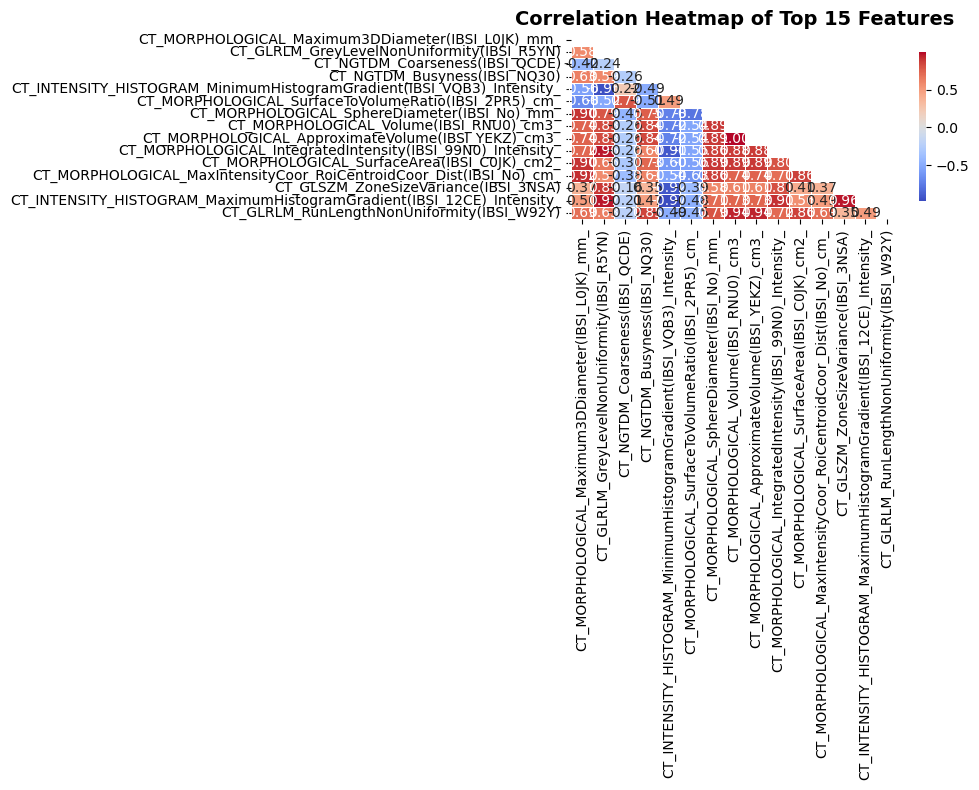

In [88]:
top_features = feature_importance_df.head(15)['Feature'].tolist()
corr = df[top_features].corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", 
            fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap of Top 15 Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/rf/x4s3m6qd51gcvc25nv1bpdl40000gn/T/ipykernel_7839/1983097901.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, y='Feature', x='Importance', palette="viridis")


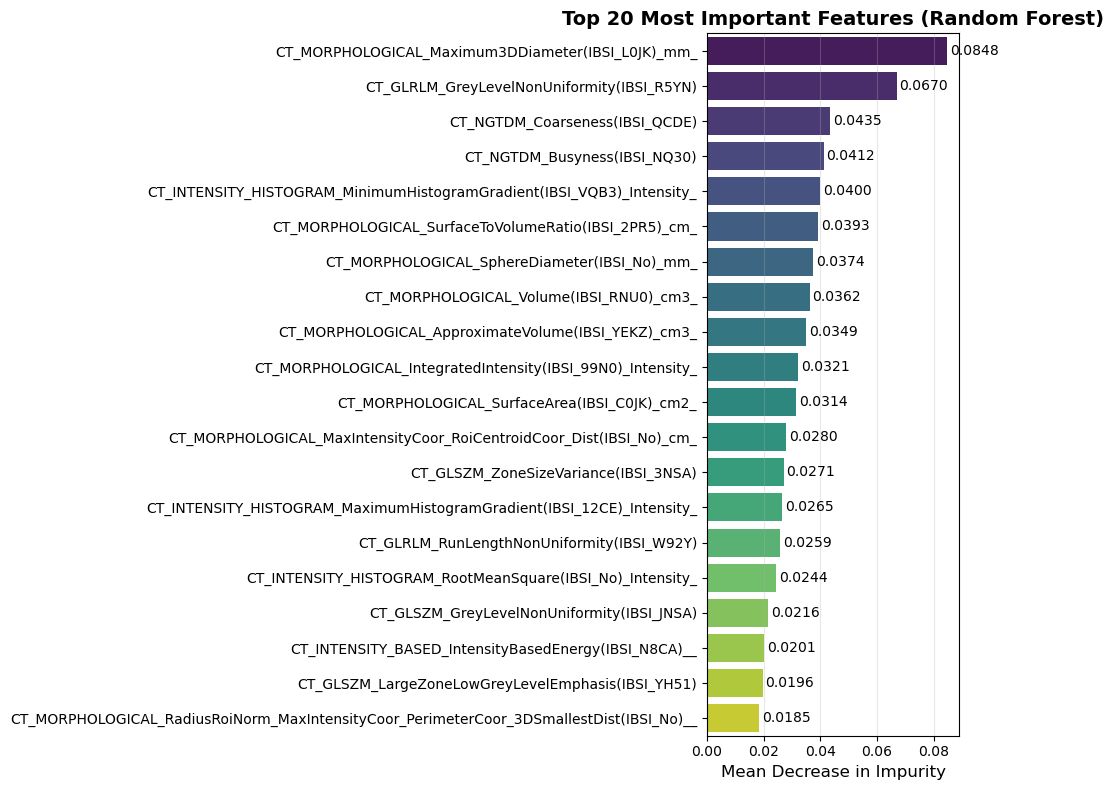

In [97]:
plt.figure(figsize=(10,8))
top20 = feature_importance_df.head(20)

sns.barplot(data=top20, y='Feature', x='Importance', palette="viridis")
plt.title("Top 20 Most Important Features (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Mean Decrease in Impurity", fontsize=12)
plt.ylabel("")
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(top20['Importance']):
    plt.text(v + 0.001, i, f"{v:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()